# Volatility Modelling

(This notebook documents my practice of time series methods. While I have taken care going through the code, there may be errors or inefficiencies. This is the nature of learning, and I will be sure to keep updating this notebook as my understanding develops)

Here we model volatility of S&P closing data using the GARCH framework. We start by converting closing prices into returns using logs. This makes return shocks become additive.

[*********************100%***********************]  1 of 1 completed

Ticker            ^GSPC
Date                   
2005-01-03  1202.079956
2005-01-04  1188.050049
2005-01-05  1183.739990
2005-01-06  1187.890015
2005-01-07  1186.189941


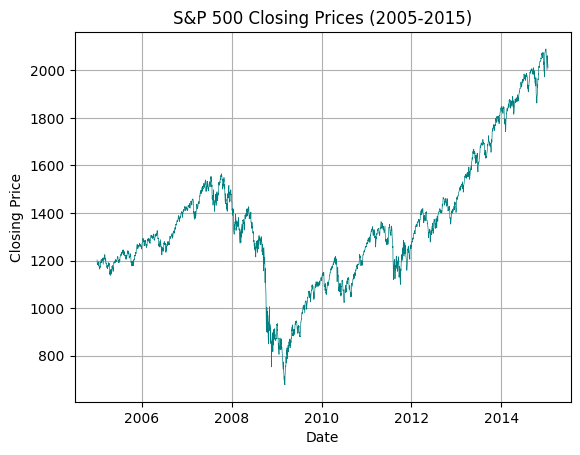

Ticker         ^GSPC
Date                
2005-01-03  0.000000
2005-01-04 -0.011740
2005-01-05 -0.003634
2005-01-06  0.003500
2005-01-07 -0.001432


Ticker,^GSPC
Date,
2005-01-03,0.000000
2005-01-04,-0.011740
2005-01-05,-0.003634
2005-01-06,0.003500
2005-01-07,-0.001432
...,...
2015-01-08,0.017730
2015-01-09,-0.008439
2015-01-12,-0.008127


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

data = yf.download(["^GSPC"], start="2005-01-01", end="2015-01-15")
closing_prices = data['Close'] 
print(closing_prices.head())

plt.plot(closing_prices, lw = 0.5, color='teal')
plt.title('S&P 500 Closing Prices (2005-2015)')
plt.grid(True)
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

returns = np.log(closing_prices).diff().fillna(0)
print(returns.head())
returns

Fetching S&P Data, convert to log returns. Additive over time. Visualise variance over time:

c:\Users\danie\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\fromnumeric.py:4230: FutureWarning: The behavior of DataFrame.var with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


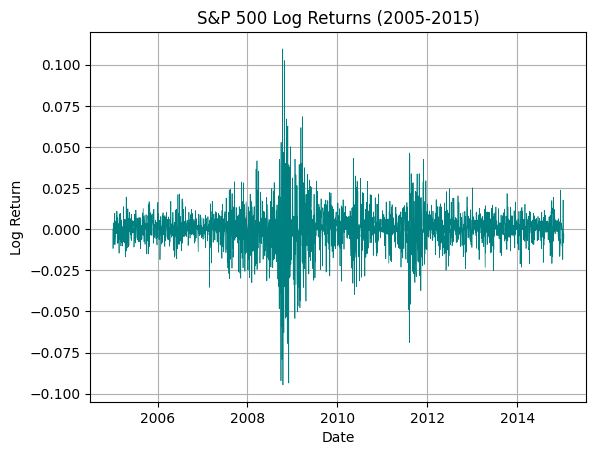

In [2]:
np.var(returns) 
plt.plot(returns, lw = 0.5, color='teal')
plt.title('S&P 500 Log Returns (2005-2015)')
plt.grid(True)
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.show()


Assume our return series has constant unconditional mean of mu. Model our return series as:

$$
r_{t} = \mu + \epsilon_{t}
$$

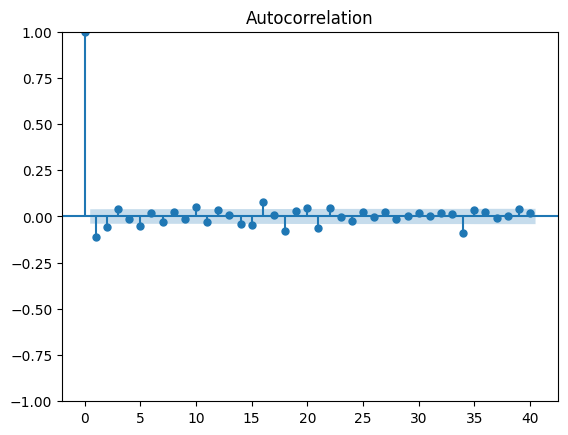

In [3]:
ret = returns.iloc[:, 0].dropna() #First column, no time index
mu = ret.mean()

epsilon = ret - mu

plot_acf(epsilon, lags=40);

Unsurprisingly, no linear predictability in residuals. Support for A1 assumption, for Weak Form EMH, no linear predictability. However we can investigate predictability in higher moments, consider ACF of squared residuals:

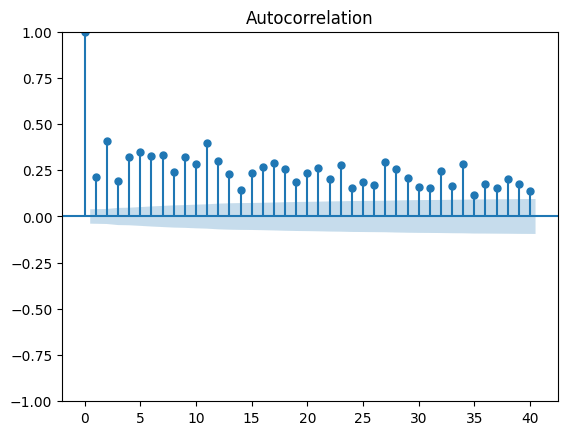

In [4]:
plot_acf(epsilon**2, lags=40);

Clear persistence. Evidence for conditional heteroscedasticity. Check if mu is statistically significant from 0.

0.0002037660411597659 0.795231209346017
Treat mean as zero


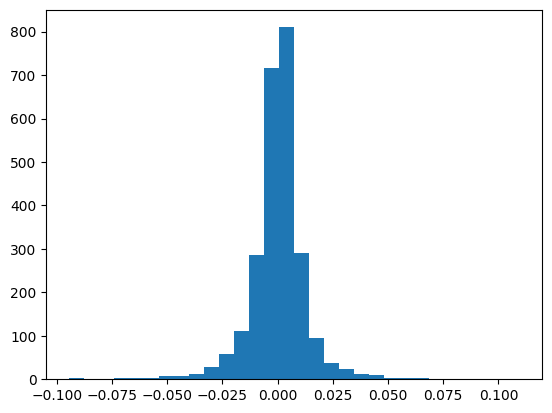

In [5]:
plt.hist(ret, bins=30)

se = ret.std(ddof=1) / np.sqrt(len(ret))
t_stat = mu / se
print(mu, t_stat)

if abs(t_stat) < 1.96:
    print("Treat mean as zero")
else:
    print("Keep nonzero mean")


At the 5% level, we can conclude that the mean is not statistically different from 0. Epsilon approximately equal to returns.

Our GARCH process accounts for conditional heteroscedasticity. Decompose our residual at time t:

$$
\epsilon_t = \sigma_tz_t, \:\:\:\:\:z_t \sim IID(0, 1)
$$

This residual follows a martingale difference process, such that:

$$
E[\epsilon_{t+1} |\Psi_t] = E[\epsilon_{t} |\Psi_t] = E[\epsilon_{t}] = 0 
$$
$$
E[\epsilon_{t} |\Psi_t] = E[\sigma_{t}z_{t}|\Psi_t] = E[\sigma_{t}|\Psi_t]E[z_t|\Psi_t] = \sigma_{t} \cdot0 = 0
$$

That is, our best guess of next period's innovation given the information up to time t is 0. One way martingale differences processes are represented, ARCH/GARCH residual decomposition. Variance of innovation predictable, however guess of next periods innovation is conditionally mean independent on the information set up to t. However volatility can be forecasted. Additionally:

$$
E[z^2_t] = 1
$$
$$
E[\epsilon^2_{t+1}|\Psi_{t}] = E[\sigma^2_{t+1}|\Psi_{t}]E[z^2_{t+1}|\Psi_{t}] = \sigma^2_t
$$

Squared zt term is 1 in expectation, variance of zt process as they are mean 0. So decomposing our residual and conditioning both components yields variance at t, as our best guess of next periods variance with this periods information is the same as this period.

Define our conditional variance:

$$
E[\sigma^2_{t+1}|\Psi_{t}] = E[\omega + \alpha\epsilon^2_{t} + \beta\sigma^2_{t}|\Psi_{t}] = \omega + \alpha\epsilon^2_{t} + \beta\sigma^2_{t}
$$

This is the equation for a standard GARCH(1,1) process. That is, our variance at time t is conditional on our previous squared residual along with an autoregressive term. Our unconditional long-run moment gives us:

$$
\bar{\sigma}^2 = \frac{\omega}{1 - \alpha - \beta}
$$

Define GARCH(1,1) Model:

In [9]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize

def garch(omega, alpha, beta, epsilon, min_var=1e-12):

    eps = np.asarray(epsilon, dtype = float)

    length = len(eps)

    if omega <= 0 or alpha < 0 or beta < 0 or (alpha + beta) >= 0.999: # Parameter validity check, baseline variance can't be <0, nor alpha/beta, sum can't exceed 1
        return np.full(length, np.nan) # Array with length of eps, all nan, marks all values as invalid/missing

    var = np.empty(length, dtype=float)

    var[0] = max(omega / (1.0 - alpha - beta), min_var) # Initial variance (unconditional)

    for i in range(1, length):
        var[i] = max(omega + alpha * eps[i - 1]**2 + beta * var[i - 1], min_var) # Very small variance causes instability, set a floor of min variance (prevents -ve var too)

    return var

The GARCH itself is very straightforward, initial variance is unconditional variance, and from there we can continue to generate our conditional variance using our GARCH equation. However, running this GARCH model without constraints frequently led to problems. There are a few important considerations with a GARCH model:

1. Non-negative parameters to ensure strictly positive variance.
$$
\omega > 0 \ \alpha \geq 0 \ \beta \geq 0 
$$

(Important to note that omega must be strictly greater than 0, as it is the baseline variance floor. This would imply that after a long, calm period the conditional variance can collapse to 0)

2. $$ \alpha + \beta < 1 $$

If the sum were equal to 1, our unconditional variance would be infinite. If it were greater than 1, it would be negative. This is our covariance stationarity condition.

Why is this important?

This means we must add safeguards for numerical optimisation. The optimization will repeatedly test many parameter combinations, including invalid ones. Our small variance floor prevents issues dividing by 0 or potential negative variance estimates.

Define MLE, we will use to fit our GARCH model:

In [10]:
def likelihood(params, epsilon):

    omega, alpha, beta = params
    
    eps = np.asarray(epsilon)

    variance = garch(omega, alpha, beta, eps)
    
    if not np.isfinite(variance).all(): # If any variance is nan or inf return a large penalty, optimizer rejects this parameter choice
        return 1e12

    llh = norm.logpdf(eps, loc=0.0, scale=np.sqrt(variance)) # Per observation log-likelihood under Normal errors, mean 0 and time varying variance
    if not np.isfinite(llh).all(): #If any log-likelihood value is invalid, penalize heavily
        return 1e12

    return -llh.sum()

Maximising log-likelihood, sum of log contributions for each data point. Find params which maximise (log) likelihood of observing the data.

In [11]:
init = (float(np.var(epsilon)), 0.03, 0.85)
bounds = [(1e-12, None), (0.0, 0.999), (0.0, 0.999)]
cons = {"type": "ineq", "fun": lambda p: 0.999 - (p[1] + p[2])}

res = minimize(
    likelihood,
    init,
    args=(epsilon,),
    method="SLSQP",
    bounds=bounds,
    constraints=[cons],
)

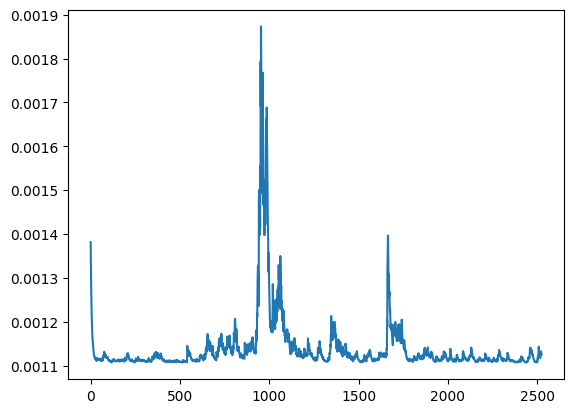

In [12]:
omega = res['x'][0] 
alpha = res['x'][1]
beta = res['x'][2]


condvar = garch(res['x'][0],res['x'][1],res['x'][2],epsilon)

plt.plot(condvar)

Can use ARCH package to estimate:

In [13]:
from arch import arch_model

model = arch_model(ret, mean = "Constant", vol = "GARCH", p = 1, q = 1)
model.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 4.0550530930134976e+21
Iteration:      2,   Func. Count:     19,   Neg. LLF: 7.836210685833009e+18
Iteration:      3,   Func. Count:     32,   Neg. LLF: 4060457254059429.5
Iteration:      4,   Func. Count:     47,   Neg. LLF: 1.871055386856964e+20
Iteration:      5,   Func. Count:     60,   Neg. LLF: 2106237767791973.8
Iteration:      6,   Func. Count:     75,   Neg. LLF: 3.5397239692099365e+27
Iteration:      7,   Func. Count:     90,   Neg. LLF: 1.9558204676112543e+28
Iteration:      8,   Func. Count:    105,   Neg. LLF: 251225921745.3534
Iteration:      9,   Func. Count:    117,   Neg. LLF: 485714204203.9279
Iteration:     10,   Func. Count:    132,   Neg. LLF: 214618822708.03967
Iteration:     11,   Func. Count:    147,   Neg. LLF: 2.00576393697493e+21
Iteration:     12,   Func. Count:    162,   Neg. LLF: 3.662018135625788e+23
Iteration:     13,   Func. Count:    176,   Neg. LLF: -5795.259975029301
Optimization terminated succes

c:\Users\danie\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001658. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                5795.26
Distribution:                  Normal   AIC:                          -11582.5
Method:            Maximum Likelihood   BIC:                          -11559.2
                                        No. Observations:                 2526
Date:                Mon, Mar 02 2026   Df Residuals:                     2525
Time:                        18:55:49   Df Model:                            1
                                  Mean Model                                  
                 coef    std err          t      P>|t|        95.0% Conf. Int.
------------------------------------------------------------------------------
mu            -0.0206  3.033e-03     -6.791  1.116e-